# Out-of-sample test on unseen tickers

Зарежда вече трениран базов модел (`best_model_base.pt`) и го тества върху тикери, които **не са в training set-а**.

Цел: да се види дали моделът е научил общи пазарни patterns или просто е запомнил тренировъчните тикери.

Процедурата за всеки нов тикер:
1. Зарежда данни (целия исторически период)
2. Прави същите features като training
3. Fit-ва StandardScaler на първите 70% от историята на този тикер (за да няма leakage)
4. Прилага scaler-а върху последните 30% (OOS test window)
5. Генерира predictions с trained модела
6. Изпълнява band trading стратегия и измерва срещу buy & hold

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import os
os.chdir(project_root)

In [2]:
import yaml
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from src.data.loader import load_raw_dataset
from src.data.preprocessor import preprocess_data
from src.data.feature_engineering import create_all_features, add_forward_log_return
from src.data.dataset import create_sequences
from src.models.transformer_model import StockTransformer
from src.simulation.engine import BacktestEngine
from src.simulation.metrics import compute_metrics
from src.simulation.rules import signal_from_return_band
from src.utils.config import load_config
from src.utils import config as _cfg

config = load_config()

config_path = _cfg.PROJECT_ROOT / "configs" / "default_config.yaml"
with config_path.open("r", encoding="utf-8") as f:
    raw_cfg = yaml.safe_load(f)
sim = raw_cfg.get("simulation", {})

initial_capital = float(sim.get("initial_capital", 100_000))
position_size_pct = float(sim.get("position_size_pct", 1.0))
entry_threshold_pct = float(sim.get("entry_threshold_pct", 0.5))
exit_threshold_pct = float(sim.get("exit_threshold_pct", -0.5))
commission_pct = float(sim.get("commission_pct", 0.1))
risk_free_rate_annual = float(sim.get("risk_free_rate_annual", 0.03))

print(f"Training tickers: {sorted(config.data.tickers)}")
print(f"Target: {config.data.target_column}, context_length: {config.data.context_length}")

Training tickers: ['AAPL', 'AMZN', 'BAC', 'COST', 'CVX', 'GOOGL', 'JNJ', 'JPM', 'KO', 'MA', 'META', 'MSFT', 'NFLX', 'NVDA', 'PEP', 'PFE', 'TSLA', 'V', 'WMT', 'XOM']
Target: log_return, context_length: 60


In [3]:
checkpoint_name = getattr(config.paths, "checkpoint_file", "best_model_base.pt")
checkpoint_path = _cfg.PROJECT_ROOT / config.paths.models_dir / checkpoint_name
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}. Run 01_train_model first.")

checkpoint = torch.load(checkpoint_path, map_location="cpu")
state_dict = checkpoint["model_state_dict"]
print(f"Loaded: {checkpoint_path.name} (modified {time.ctime(checkpoint_path.stat().st_mtime)})")
print(f"Checkpoint epoch={checkpoint.get('epoch', '?') + 1}, val_loss={checkpoint.get('score', '?'):.6f}")

input_dim_ck = state_dict["input_projection.weight"].shape[1]
d_model = state_dict["input_projection.weight"].shape[0]
n_layers = len([k for k in state_dict if "encoder.layers" in k and "self_attention.w_q.weight" in k])
d_ff = state_dict["encoder.layers.0.feed_forward.linear1.weight"].shape[0]

model = StockTransformer(
    input_dim=input_dim_ck,
    d_model=d_model,
    n_heads=config.model.n_heads,
    n_layers=n_layers,
    d_ff=d_ff,
    dropout=config.model.dropout,
    activation=config.model.activation,
    prediction_horizon=config.data.prediction_horizon,
)
model.load_state_dict(state_dict)
model.eval()
print(f"Model: input_dim={input_dim_ck}, d_model={d_model}, n_layers={n_layers}")

Loaded: best_model_base.pt (modified Thu May 28 14:09:11 2026)
Checkpoint epoch=18, val_loss=0.000110
Model: input_dim=34, d_model=256, n_layers=6


In [4]:
# Unseen tickers (NOT in training set), mixed across sectors
TRAINING_TICKERS = set(config.data.tickers)
UNSEEN_TICKERS = [
    # Tech (different from training tech)
    "ORCL", "IBM", "INTC", "AMD", "ADBE",
    # Finance (different)
    "GS", "MS", "WFC",
    # Healthcare (different)
    "MRK", "ABBV", "UNH",
    # Consumer / retail
    "DIS", "NKE", "MCD", "SBUX", "HD", "LOW",
    # Industrials (sector not in training!)
    "BA", "CAT", "GE",
    # Telecom (sector not in training!)
    "T", "VZ",
    # Auto (sector not in training!)
    "F",
]

overlap = sorted(TRAINING_TICKERS & set(UNSEEN_TICKERS))
if overlap:
    raise ValueError(f"Unseen tickers must NOT overlap with training tickers: {overlap}")

print(f"Unseen tickers ({len(UNSEEN_TICKERS)}): {UNSEEN_TICKERS}")

print("\nLoading raw dataset...")
raw_df = load_raw_dataset(config=config)
print(f"Raw dataset: {len(raw_df):,} rows, tickers={raw_df['symbol'].nunique() if 'symbol' in raw_df.columns else 'NA'}")

if config.data.start_date:
    raw_df["date"] = pd.to_datetime(raw_df["date"])
    raw_df = raw_df[raw_df["date"] >= pd.to_datetime(config.data.start_date)]
    print(f"After start_date {config.data.start_date}: {len(raw_df):,} rows")

missing = [t for t in UNSEEN_TICKERS if t not in set(raw_df["symbol"].unique())]
if missing:
    print(f"WARNING: tickers missing from dataset: {missing}")
    UNSEEN_TICKERS = [t for t in UNSEEN_TICKERS if t not in missing]

Unseen tickers (23): ['ORCL', 'IBM', 'INTC', 'AMD', 'ADBE', 'GS', 'MS', 'WFC', 'MRK', 'ABBV', 'UNH', 'DIS', 'NKE', 'MCD', 'SBUX', 'HD', 'LOW', 'BA', 'CAT', 'GE', 'T', 'VZ', 'F']

Loading raw dataset...
Raw dataset: 1,048,575 rows, tickers=321
After start_date 2015-01-01: 460,245 rows


In [5]:
PRICE_COL = config.data.price_column
TARGET_COL = config.data.target_column
CTX = config.data.context_length
TRAIN_SPLIT = config.data.train_split
VAL_SPLIT = config.data.val_split

# Smart long-only strategy constants. These are intentionally fixed so the
# evaluation measures the model, not manual parameter tuning by the user.
STRATEGY_NAME = "smart_long_only"
MIN_TRADING_DAYS = 80

def build_features_for_ticker(ticker_df):
    """Same feature pipeline as training, per ticker."""
    df = ticker_df.copy()
    df, _ = preprocess_data(
        df,
        handle_missing=True,
        missing_method="forward_fill",
        handle_outliers_flag=True,
        outliers_method="clip",
        normalize=False,
        date_column="date",
        symbol_column="symbol",
    )
    df = create_all_features(
        df,
        price_column=PRICE_COL,
        windows=config.data.features.windows,
        lags=[1, 2, 3, 5, 10] if config.data.features.lag_features else [],
        add_technical=config.data.features.technical_indicators,
        add_lags=config.data.features.lag_features,
        add_temporal=config.data.features.temporal_features,
        add_volume=True,
        simplified=config.data.features.simplified,
        symbol_column="symbol",
    )
    if TARGET_COL == "log_return":
        df = add_forward_log_return(df, price_column=PRICE_COL, target_column=TARGET_COL, symbol_column="symbol")
    return df.dropna().sort_values("date").reset_index(drop=True)


def run_unseen_backtest(ticker, raw_df):
    ticker_df = raw_df[raw_df["symbol"] == ticker]
    if len(ticker_df) < 200:
        return None

    full = build_features_for_ticker(ticker_df)
    if len(full) < CTX + 50:
        return None

    feature_columns = [
        c for c in full.columns
        if c not in {"date", "symbol", PRICE_COL, TARGET_COL}
        and full[c].dtype in ["float64", "int64", "float32", "int32"]
    ]
    if len(feature_columns) != input_dim_ck:
        raise ValueError(
            f"{ticker}: feature count {len(feature_columns)} != model input_dim {input_dim_ck}"
        )

    # Per-ticker scaler: fit on first 70%, apply everywhere. Test window = last 15%.
    n = len(full)
    train_end = int(n * TRAIN_SPLIT)
    test_start = int(n * (TRAIN_SPLIT + VAL_SPLIT))

    scaler = StandardScaler().fit(full.iloc[:train_end][feature_columns])
    scaled = full.copy()
    scaled[feature_columns] = scaler.transform(scaled[feature_columns])

    # Build sequences over the TEST window. We need CTX-1 days of history before test_start.
    seq_start = max(0, test_start - CTX + 1)
    seg = scaled.iloc[seq_start:].reset_index(drop=True)
    stacked = np.column_stack([
        seg[feature_columns].values,
        seg[TARGET_COL].values.reshape(-1, 1),
    ])
    seq_X, seq_y = create_sequences(stacked, CTX, config.data.prediction_horizon)
    if len(seq_X) == 0:
        return None

    X = seq_X[:, :, :-1]
    actual_returns = seq_y[:, -1, -1] if config.data.prediction_horizon == 1 else seq_y[:, :, -1][:, -1]

    prices = seg[PRICE_COL].values[CTX : CTX + len(seq_X)]
    dates = seg["date"].values[CTX : CTX + len(seq_X)]

    pred_batches = []
    with torch.no_grad():
        for start in range(0, len(X), config.training.batch_size):
            batch_x = torch.FloatTensor(X[start : start + config.training.batch_size])
            pred_batches.append(model(batch_x).detach().cpu())
    predicted_returns = torch.cat(pred_batches).numpy().reshape(-1)

    engine = BacktestEngine(
        initial_capital=initial_capital,
        position_size_pct=position_size_pct,
        entry_threshold_pct=entry_threshold_pct,
        exit_threshold_pct=exit_threshold_pct,
        commission_pct=commission_pct,
    )
    if len(prices) < MIN_TRADING_DAYS:
        return None

    result = engine.run_smart_long_only(
        prices=prices,
        predicted_returns=predicted_returns,
        dates=dates,
    )
    metrics = compute_metrics(
        result,
        initial_capital=initial_capital,
        risk_free_rate_annual=risk_free_rate_annual,
        prices=prices,
    )
    directional_acc = float(np.mean(np.sign(predicted_returns) == np.sign(actual_returns)))
    n_buy_trades = sum(1 for t in result.trades if t.side == "buy")

    return {
        "ticker": ticker,
        "days": len(prices),
        "strategy": STRATEGY_NAME,
        "buy_trade_pct": 100 * n_buy_trades / len(prices),
        "directional_accuracy_pct": 100 * directional_acc,
        "strategy_return_pct": metrics.total_return_pct,
        "buy_hold_return_pct": metrics.buy_and_hold_return_pct,
        "excess_vs_bh_pct": metrics.excess_return_vs_bh_pct,
        "max_drawdown_pct": metrics.max_drawdown_pct,
        "sharpe": metrics.sharpe_ratio_annual,
        "trades": metrics.num_trades,
        "_result": result,
        "_prices": prices,
    }

In [6]:
results = []
for tk in UNSEEN_TICKERS:
    try:
        out = run_unseen_backtest(tk, raw_df)
    except Exception as e:
        print(f"  {tk}: FAILED ({e})")
        continue
    if out is None:
        print(f"  {tk}: skipped (not enough data)")
        continue
    print(f"  {tk}: days={out['days']} trades={out['trades']} "
          f"strat={out['strategy_return_pct']:+.2f}%  bh={out['buy_hold_return_pct']:+.2f}%  "
          f"excess={out['excess_vs_bh_pct']:+.2f}%")
    results.append(out)

summary_df = (
    pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in results])
    .sort_values("excess_vs_bh_pct", ascending=False)
)

print("\n" + "=" * 90)
print("OUT-OF-SAMPLE TICKER BACKTEST")
print("=" * 90)
display(summary_df.style.format({
    "buy_trade_pct": "{:.1f}%",
    "directional_accuracy_pct": "{:.1f}%",
    "strategy_return_pct": "{:.2f}%",
    "buy_hold_return_pct": "{:.2f}%",
    "excess_vs_bh_pct": "{:+.2f}%",
    "max_drawdown_pct": "{:.2f}%",
    "sharpe": "{:.3f}",
}))

print("\nAggregate (unseen tickers):")
print(f"  Tickers tested:              {len(summary_df)}")
print(f"  Mean strategy return:        {summary_df['strategy_return_pct'].mean():.2f}%")
print(f"  Mean buy & hold return:      {summary_df['buy_hold_return_pct'].mean():.2f}%")
print(f"  Mean excess vs B&H:          {summary_df['excess_vs_bh_pct'].mean():+.2f}%")
print(f"  Median excess vs B&H:        {summary_df['excess_vs_bh_pct'].median():+.2f}%")
print(f"  Tickers beating B&H:         {(summary_df['excess_vs_bh_pct'] > 0).sum()} / {len(summary_df)}")
print(f"  Mean directional accuracy:   {summary_df['directional_accuracy_pct'].mean():.2f}%")
print(f"  Mean trades per ticker:      {summary_df['trades'].mean():.1f}")

  IBM: days=214 trades=8 strat=-3.08%  bh=-6.61%  excess=+3.53%
  INTC: days=214 trades=5 strat=-4.24%  bh=-9.59%  excess=+5.35%
  AMD: days=214 trades=0 strat=+0.00%  bh=+108.86%  excess=-108.86%
  ADBE: days=214 trades=9 strat=+4.49%  bh=+61.14%  excess=-56.65%
  GS: days=214 trades=8 strat=-6.14%  bh=-8.50%  excess=+2.36%
  MS: days=214 trades=4 strat=-1.51%  bh=-1.92%  excess=+0.41%
  MRK: days=214 trades=9 strat=+1.93%  bh=-1.22%  excess=+3.15%
  ABBV: days=214 trades=6 strat=-0.41%  bh=+5.13%  excess=-5.53%
  DIS: days=214 trades=5 strat=+2.56%  bh=-14.60%  excess=+17.16%
  MCD: days=214 trades=13 strat=-0.06%  bh=+14.64%  excess=-14.70%
  HD: days=214 trades=10 strat=+2.92%  bh=+27.87%  excess=-24.94%
  LOW: days=214 trades=8 strat=+3.63%  bh=+39.09%  excess=-35.45%
  BA: days=213 trades=0 strat=+0.00%  bh=-55.89%  excess=+55.89%
  CAT: days=214 trades=6 strat=+0.86%  bh=+4.90%  excess=-4.05%
  GE: days=214 trades=0 strat=+0.00%  bh=-46.74%  excess=+46.74%
  F: days=214 trades=0

,ticker,days,strategy,buy_trade_pct,directional_accuracy_pct,strategy_return_pct,buy_hold_return_pct,excess_vs_bh_pct,max_drawdown_pct,sharpe,trades
12,BA,213,smart_long_only,0.0%,43.7%,0.00%,-55.89%,+55.89%,0.00%,0.000,0
14,GE,214,smart_long_only,0.0%,40.2%,0.00%,-46.74%,+46.74%,0.00%,0.000,0
15,F,214,smart_long_only,0.0%,43.0%,0.00%,-24.49%,+24.49%,0.00%,0.000,0
8,DIS,214,smart_long_only,1.4%,44.4%,2.56%,-14.60%,+17.16%,2.23%,0.027,5
1,INTC,214,smart_long_only,1.4%,48.1%,-4.24%,-9.59%,+5.35%,6.58%,-1.323,5
0,IBM,214,smart_long_only,1.9%,51.4%,-3.08%,-6.61%,+3.53%,4.54%,-1.489,8
6,MRK,214,smart_long_only,2.3%,43.9%,1.93%,-1.22%,+3.15%,1.74%,-0.150,9
4,GS,214,smart_long_only,1.9%,49.1%,-6.14%,-8.50%,+2.36%,6.14%,-3.153,8
5,MS,214,smart_long_only,0.9%,49.1%,-1.51%,-1.92%,+0.41%,3.02%,-1.646,4
13,CAT,214,smart_long_only,1.4%,52.8%,0.86%,4.90%,-4.05%,1.82%,-0.499,6



Aggregate (unseen tickers):
  Tickers tested:              16
  Mean strategy return:        0.06%
  Mean buy & hold return:      5.75%
  Mean excess vs B&H:          -5.69%
  Median excess vs B&H:        +1.39%
  Tickers beating B&H:         9 / 16
  Mean directional accuracy:   48.70%
  Mean trades per ticker:      5.7


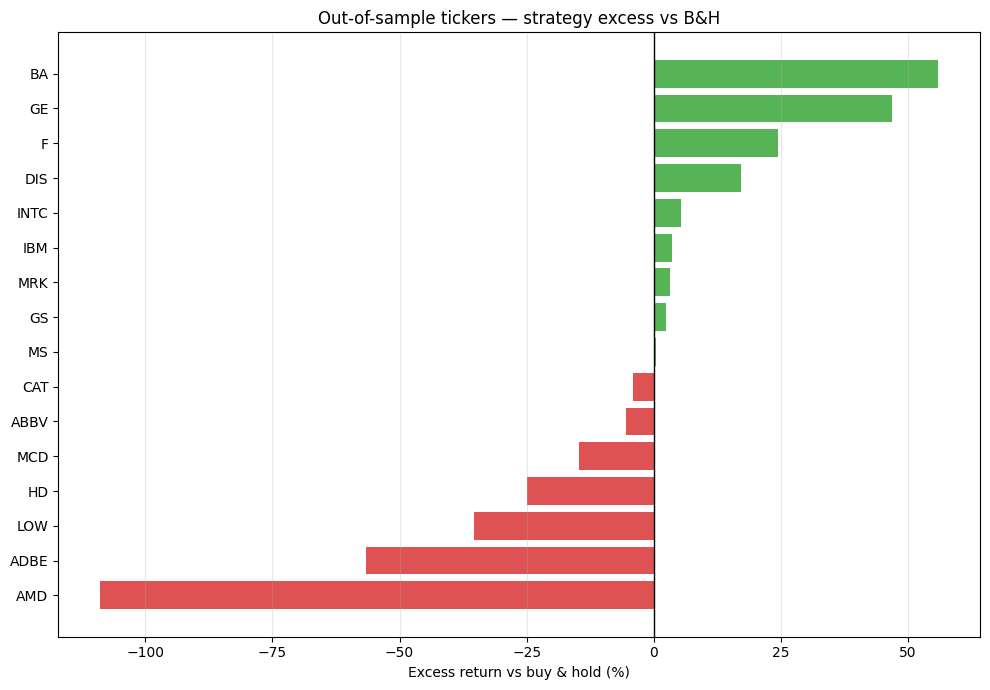

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_df = summary_df.sort_values("excess_vs_bh_pct", ascending=True)
colors = np.where(plot_df["excess_vs_bh_pct"] > 0, "C2", "C3")
ax.barh(plot_df["ticker"], plot_df["excess_vs_bh_pct"], color=colors, alpha=0.8)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Excess return vs buy & hold (%)")
ax.set_title("Out-of-sample tickers — strategy excess vs B&H")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()